## 1. Configurações e Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
# df = pd.read_csv("data/recalls_stellantis_brasil.csv")
df = pd.read_excel("data/dataset.xlsx")
df.head()

,Modelo,Idade Veículo,Km,Reclamações,Recall
0,Strada,3,46657,1,Não
1,Pulse,7,123826,4,Sim
2,Fastback,0,17903,1,Não
3,Renegade,6,82040,5,Não
4,Toro,8,144350,7,Sim


## 2. Validação e Pré-processamento do Dataset

### 2.1. Tratamenos básicos

In [3]:
print(f"O Dataset possui {df.shape[1]} colunas e {df.shape[0]} linhas.")

O Dataset possui 5 colunas e 500 linhas.


In [4]:
df.dtypes

Modelo           object
Idade Veículo     int64
Km                int64
Reclamações       int64
Recall           object
dtype: object

In [18]:
# Normalização de informações tipo string:

df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

for col in df.columns:
    if df[col].dtype == "O":
        df[col] = df[col].str.strip().str.lower().str.replace(" ", "_", regex=False)

df = df.rename(columns={"idade_veículo": "idade_veiculo", "reclamações": "reclamacoes"})
df.head()

,modelo,idade_veiculo,km,reclamacoes,recall,km_por_ano
0,strada,3,46657,1,não,15552.333333
1,pulse,7,123826,4,sim,17689.428571
2,fastback,0,17903,1,não,17903.000000
3,renegade,6,82040,5,não,13673.333333
4,toro,8,144350,7,sim,18043.750000


In [6]:
# Proporção da variável target

pd.DataFrame([df["recall"].value_counts(), df["recall"].value_counts(normalize=True)*100]).T

,count,proportion
recall,,
não,261.0,52.2
sim,239.0,47.8


### 2.2. Lidando com NULL e colunas extras

In [7]:
df.isna().sum()

modelo           0
idade_veículo    0
km               0
reclamações      0
recall           0
dtype: int64

## 3. Exploração dos Dados

### 3.1. Variáveis Numéricas

In [19]:
# Pensando em incluir uma variavel que acho interessante, km/idade. Vamos realizar alguns testes
# É importante verificar os casos de idade = 0 para não dar erro na divisão

df["idade_veiculo"].value_counts().sort_index()

idade_veiculo
0    61
1    58
2    59
3    48
4    55
5    56
6    55
7    47
8    61
Name: count, dtype: int64

In [20]:
# Para essa situação, vamos só substituir por 1 para não quebrar o código

df["km_por_ano"] = df["km"] / df["idade_veiculo"].replace(0, 1)

In [21]:
# Olhando para os valores, percebemos uma diferença relativametne interessantes por variável entre com recall e sem recall
# O problema é a variável nova, aparentemente os dois grupos se comportam de maneira muito parecida. Olhando os valores
# Media: 11.9k x 12.3k (~3%)
# Mediana: 11.7k x 12.0k (~3%)

df.groupby("recall")[["km", "idade_veiculo", "reclamacoes", "km_por_ano"]].agg(["mean", "median"]).round(2)

km          idade_veiculo        reclamacoes        km_por_ano  \
            mean   median          mean median        mean median       mean   
recall                                                                         
não     54687.88  47526.0          2.72    2.0        2.60    2.0   20356.29   
sim     94031.88  97149.0          5.26    5.0        4.93    5.0   18885.16   

                  
          median  
recall            
não     18825.00  
sim     17976.14

In [26]:
# Vamos fazer uma analise bi-variada simples de correlação sobre a coluna km_por_ano
# Olhando a correção entre recall e km_por_ano, 0.03 -> muito fraca, mais um ponto para o descarte

# Outro problema que surgiu aqui é a questão de idade_veiculo e km. Elas tem um valor bem alto de correlação entre si. Isso talvez entre como um caso de multicolinearidade. 
# Pensando nas variáveis diremtante, elas dizem coisas muito parecidas, pois carros mais velhos tendem a ter mais KMs rodados mesmo.
# Isso vai ser importante na hora de rodar os modelos.
# Dados que correlação entre elas e o target ser muito próxima (0.3158 e 0.3163), talvez valha utilizar apenas 1, a decidir.

df_corr = df.copy()
df_corr["recall_bin"] = (df_corr["recall"] == "sim").astype(int)

df_corr[["km", "idade_veiculo", "reclamacoes", "km_por_ano", "recall_bin"]].corr()

,km,idade_veiculo,reclamacoes,km_por_ano,recall_bin
km,1.000000,0.889323,0.688539,0.260550,0.315804
idade_veiculo,0.889323,1.000000,0.723382,-0.044924,0.316343
reclamacoes,0.688539,0.723382,1.000000,0.023151,0.337748
km_por_ano,0.260550,-0.044924,0.023151,1.000000,0.030743
recall_bin,0.315804,0.316343,0.337748,0.030743,1.000000


### 3.2. Variáveis Categóricas

In [27]:
# Olhando para o Modelo agora, para ver a relação dela com a target
# Como  é categórica, correlação numérica (tipo Pearson) não vai servir
# O jeito certo de comparar é taxa de recall por grupo, junto com o desgaste médio de cada um (idade/km/reclamações), pra saber se a diferença é um efeito próprio

# Tem bastante bastante casos por categoria (menos em desconhecido, mas isso foi input de Null)
# A diferença entre o maior e menor é bem interessante para uma olhada com mais detalhe (11.5% x 46.2%)

# É legal ver as infos numéricas aqui para ver se tem um padrão ou não, tipo mais antigo mais recall, porém ram_2500 e jeep_grand_cherokee parecem não ser
# necessariamente verdade, porque eles vão no contrafluxo isso (alto recall x baixos valores das outras variáveis)

resumo_modelo = df.groupby("modelo")["recall"].agg(
    total_casos="count",
    taxa_recall=lambda x: (x == "sim").mean(),
).sort_values(by="taxa_recall", ascending=False)

resumo_modelo = resumo_modelo.join(
    df.groupby("modelo")[["idade_veiculo", "km", "reclamacoes"]].mean().round(1)
)

resumo_modelo

,total_casos,taxa_recall,idade_veiculo,km,reclamacoes
modelo,,,,,
ram_2500,80,0.462500,7.4,87724.2,6.7
fiat_grand_siena,80,0.412500,10.7,127034.6,7.9
fiat_uno,88,0.409091,10.8,122310.3,8.0
jeep_grand_cherokee,107,0.373832,6.6,83509.7,5.4
desconhecido,11,0.363636,7.5,92187.5,5.6
fiat_palio,80,0.362500,12.2,143093.1,8.9
jeep_renegade,138,0.362319,6.4,77562.4,5.0
jeep_compass,149,0.214765,5.4,64439.4,4.2
fiat_strada,128,0.164062,5.0,57868.1,3.5


In [28]:
# Pra cravar o que estávemos discutindo antes, rodamos um teste de qui-quadrado entre modelo e recall pois são variáveis categóricas
# Com o resultado de Chi² = 66.18 e p-valor = 0.0000 -> podemos dizer que não são independentes, e é estatistiticamente significativo a relação

from scipy.stats import chi2_contingency

tabela = pd.crosstab(df["modelo"], df["recall"])
chi2, p, dof, expected = chi2_contingency(tabela)
print(f"Chi2: {chi2:.2f}, p-valor: {p:.5f}")

Chi2: 66.18, p-valor: 0.00000


In [29]:
# Olhando mais a fundo os modelos de ram_500 e grand_cherokee
# É interessantes olhar que 2017 tem um valor bem alto, mas como temos muitos recortes, com pouquissimos carros por recorte não da pra cravar nada ainda

ano_atual = 2026
df["ano_fabricacao_calc"] = ano_atual - df["idade_veiculo"]

subset_ram = df[df["modelo"] == "ram_2500"]

taxa_ram = subset_ram.groupby("ano_fabricacao_calc")["recall"].apply(lambda x: (x == "sim").mean())
contagem_ram = subset_ram.groupby("ano_fabricacao_calc").size()

pd.DataFrame({"taxa_recall": taxa_ram, "total_casos": contagem_ram})

,taxa_recall,total_casos
ano_fabricacao_calc,,
2014.0,0.555556,9
2015.0,0.500000,6
2016.0,0.500000,10
2017.0,0.909091,11
2018.0,0.500000,8
2019.0,0.200000,10
2020.0,0.000000,3
2021.0,0.625000,8
2022.0,0.000000,3


In [30]:
subset_gc = df[df["modelo"] == "jeep_grand_cherokee"]

taxa_gc = subset_gc.groupby("ano_fabricacao_calc")["recall"].apply(lambda x: (x == "sim").mean())
contagem_gc = subset_gc.groupby("ano_fabricacao_calc").size()

pd.DataFrame({"taxa_recall": taxa_gc, "total_casos": contagem_gc})

,taxa_recall,total_casos
ano_fabricacao_calc,,
2014.0,0.555556,9
2015.0,0.500000,6
2016.0,0.400000,10
2017.0,0.777778,9
2018.0,0.363636,11
2019.0,0.500000,8
2020.0,0.312500,16
2021.0,0.000000,4
2022.0,0.300000,10


In [31]:
# Isolando apenas os modelos ram_2500 e grand_cherokee, a taxa de recall deles fabricados em 2017 é mais alta que o restante dos anos
# Isso pode indicar algum tipo de problema específico para esses modelos de 2017.
# Como a amostra ainda é pequena dado o recorte, não consigo cravar mas parece um padrão interessante de analisar.

df.groupby("ano_fabricacao_calc")["recall"].agg(
    total_casos="count",
    taxa_recall=lambda x: (x == "sim").mean(),
).sort_index()

,total_casos,taxa_recall
ano_fabricacao_calc,,
2011.0,22,0.363636
2012.0,26,0.538462
2013.0,37,0.459459
2014.0,53,0.433962
2015.0,61,0.426230
2016.0,104,0.509615
2017.0,95,0.536842
2018.0,88,0.340909
2019.0,86,0.220930


## 4. Escolha de Modelos

### 4.1. Escolha das Features e Separação de Datasets

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
# Não utilizei todas as features analisadas anteriormente. Uma vez que algumas não faziam sentido ficou assim:
# - modelo: utilizada pois apresenta uma relação bem interessantes com o target
# - idade_veiculo: utilizada pois também traz informações importantes de uso do veículo
# - km: removida pois apresenta uma relação muito forte com idade_veiculo, acaba trazendo o memso nível de informação -> vale testar com e sem
# - reclamacoes: utilizada pois aparentemente tem uma relação com recall
# - reclamacoes_ausente: utilizada pois é um sinal para os modelos sobre o input da info reclamações, para minimizar viés trazido pelo input
# - km_por_ano: removida pois apresentou um sinal muito fraco com recall
# - ano_fabricacao_calc: utilizada apenas na EDA
# - recall: target que queremos prever

categorical = ["modelo"]
numerical = ["idade_veiculo", "reclamacoes", "reclamacoes_ausente"]
target = "recall"

In [34]:
X = df[categorical + numerical].copy()
y = df[target].map({"não": 0, "sim": 1})

In [35]:
# Vamos utilizar a estratégia Treino / Validação / Teste -> então teremos 3 datasets
# O ideal é 60% / 20 % / 20% -> como vamos usar o train_test_split, vamos colocar 25% no valor pq ele pega 25% dos 80% do primeiro split, resultando nos 20%

test_size = 0.2
val_size = 0.25
random_state = 42

In [36]:
X_full, X_test, y_full, y_test = train_test_split(
                                                X, 
                                                y, 
                                                test_size=test_size, 
                                                random_state=random_state,
                                                stratify=y
                                                )

In [37]:
X_train, X_val, y_train, y_val = train_test_split(
                                                X_full, 
                                                y_full, 
                                                test_size=val_size, 
                                                random_state=random_state,
                                                stratify=y_full
                                                )

In [38]:
# Validando a estratificação da base nos 3 datasets

(pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Treino": y_train.value_counts(normalize=True),
    "Validação": y_val.value_counts(normalize=True),
    "Teste": y_test.value_counts(normalize=True)
})*100).round(2)

,Original,Treino,Validação,Teste
recall,,,,
0,70.2,70.17,70.5,70.0
1,29.8,29.83,29.5,30.0


In [39]:
print(f"O DF de Treino possui {X_train.shape[1]} colunas e {X_train.shape[0]} linhas.")
print(f"O DF de Validação possui {X_val.shape[1]} colunas e {X_val.shape[0]} linhas.")
print(f"O DF de Teste possui {X_test.shape[1]} colunas e {X_test.shape[0]} linhas.")

O DF de Treino possui 4 colunas e 600 linhas.
O DF de Validação possui 4 colunas e 200 linhas.
O DF de Teste possui 4 colunas e 200 linhas.


### 4.2. Treinar um baseline de alguns modelos

In [40]:
# !pip install feature_engine

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn import metrics
from sklearn.pipeline import Pipeline
# from sklearn.metrics import 

# Modelo 1
from sklearn.linear_model import LogisticRegression

# Modelo 2
from sklearn.tree import DecisionTreeClassifier

# Modelo 3
from sklearn import ensemble



#### 4.2.1. Pré processamento

In [42]:
# Vamos aplicar uma padronização às colunas, porém para cada tipo temos que aplicar uma estratégica
# - Categóricas: como temos apenas 1 coluna categórica e ele tem apenas 9 opções, utilizar o OneHotEncoder direto é muito tranquilo, a dimensionalidade não cresce muito
# - Numéricas: aqui apliquei o MinMax para apenas padronizar os valores no intervalo 0 - 1, bem simples
# Como irei utilizar isso em todos os modelos, mantenho isso em uma sessão anterior separada

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numerical),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical) 
    ]
)

#### 4.2.2. Regressão Logística

In [43]:
# Selecionei um modelo base mais simples de analisar para ter um baseline de saída, só para entender se estamos chegando em algo e como melhorar

reg_log = LogisticRegression(
                        penalty = None,
                        random_state = random_state,
                        max_iter = 1000000
                        )

In [44]:
# Pipeline para rodar as transformações e o modelo

reg_log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", reg_log)
    ]
)

In [45]:
# Aqui já deixei implementado via pipeline para podermos melhorar o pré-processamento de forma mais rápida e simples

features = categorical + numerical
reg_log_pipeline.fit(X_train[features], y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
y_train_reg_log_predict = reg_log_pipeline.predict(X_train[features])
y_train_reg_log_proba = reg_log_pipeline.predict_proba(X_train[features])[:, 1]

In [47]:
# Para avaliar o modelo, como está um pouco desbalanceado, vamos olhar métricas
# além da Acurácia. Então olhei também de forma simplificada Precision/Recall/F1
# e a Matriz de Confusão, porque aqui temos "erros" piores

# A avaliação inicial é entre Treino e Validação

y_val_reg_log_predict = reg_log_pipeline.predict(X_val[features])
y_val_reg_log_proba = reg_log_pipeline.predict_proba(X_val[features])[:, 1]

#### 4.2.3. Árvore de Decisão

In [48]:
# Outro modelo relativamente simples escolhido para testes é um algoritimo de Árvore de Decisão

tree = DecisionTreeClassifier(
                        max_depth=5,
                        min_samples_leaf=20,
                        random_state=random_state
)

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", tree)
    ]
)

tree_pipeline.fit(X_train[features], y_train)

# Métricas de Treino
y_train_tree_predict = tree_pipeline.predict(X_train[features])
y_train_tree_proba = tree_pipeline.predict_proba(X_train[features])[:, 1]

# Métricas de Validação
y_val_tree_predict = tree_pipeline.predict(X_val[features])
y_val_tree_proba = tree_pipeline.predict_proba(X_val[features])[:, 1]

#### 4.2.4. Random Forest

In [49]:
# Outro modelo um pouco mais complexo é o Random Forest

rand_forest = ensemble.RandomForestClassifier(
                        random_state = random_state,
                        min_samples_leaf = 20,
                        n_jobs = -1, # todos os nucleos
                        n_estimators = 1000
                        )

rand_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rand_forest)
    ]
)

rand_forest_pipeline.fit(X_train[features], y_train)

# Métricas de Treino
y_train_rand_forest_predict = rand_forest_pipeline.predict(X_train[features])
y_train_rand_forest_proba = rand_forest_pipeline.predict_proba(X_train[features])[:, 1]

# Métricas de Validação
y_val_rand_forest_predict = rand_forest_pipeline.predict(X_val[features])
y_val_rand_forest_proba = rand_forest_pipeline.predict_proba(X_val[features])[:, 1]

#### 4.2.5. Compilado de Comparação entre Modelos

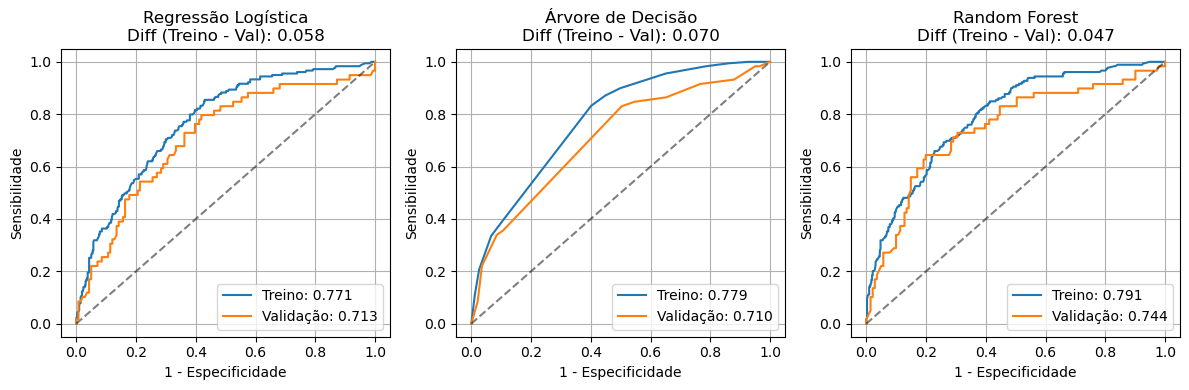

In [50]:
# Curva ROC dos 3 modelos, pra poder ter uma comparação mais visual
# A ideia aqui é dar uma olhada no descolamento entre as curvas de Treino e Validação
# E verificar quanto a mais saimos da linha de refêrencia base

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

modelos = [
    ("Regressão Logística", y_train_reg_log_proba, y_val_reg_log_proba),
    ("Árvore de Decisão", y_train_tree_proba, y_val_tree_proba),
    ("Random Forest", y_train_rand_forest_proba, y_val_rand_forest_proba)
]

for ax, (nome, proba_train, proba_val) in zip(axes, modelos):

    roc_train = metrics.roc_curve(y_train, proba_train)
    roc_val = metrics.roc_curve(y_val, proba_val)
    auc_train = metrics.roc_auc_score(y_train, proba_train)
    auc_val = metrics.roc_auc_score(y_val, proba_val)
    
    diff = auc_train - auc_val
    
    ax.plot(roc_train[0], roc_train[1], label=f"Treino: {auc_train:.3f}")
    ax.plot(roc_val[0], roc_val[1], label=f"Validação: {auc_val:.3f}")
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5) 
    
    ax.set_title(f"{nome}\nDiff (Treino - Val): {diff:.3f}")
    ax.set_xlabel("1 - Especificidade")
    ax.set_ylabel("Sensibilidade")
    ax.grid(True)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [51]:
modelos_proba_val = {
    "Regressão Logística": y_val_reg_log_proba,
    "Árvore de Decisão": y_val_tree_proba,
    "Random Forest": y_val_rand_forest_proba,
}

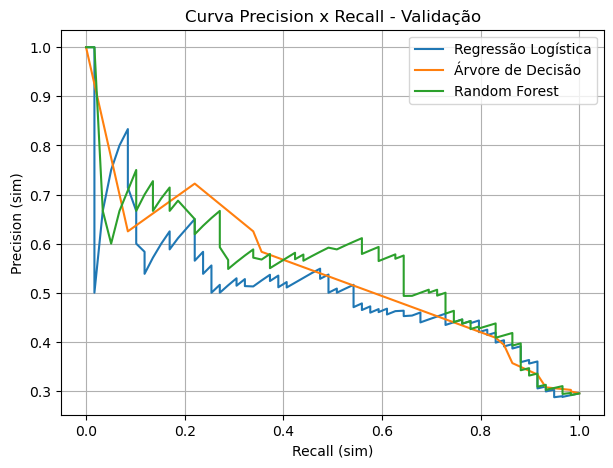

In [52]:
# Aqui estamos olhando de fato para as métricas dos modelos de forma direta para visualizar quem está desempenhando melhor 
# ao alterarmos um limiar de Recall
# O modeo de Árvore apresenta um corportamento que acaba saltando em alguns pontos, parecendo que para esse dataset não é o mais adequado.
# Focando entre RF e Regressão Log, acredito olhando aqui e a curva ROC, que o modelo de RF vai ajudar mais a discretizar nossos casos.
# Da para perceber que a a linha de plot de RF está consistentemente acima da de Reg. Log. Indicando uma precisão melhor em diversos pontos
# de recall que o gráfico plota

plt.figure(figsize=(7, 5))

for nome, proba_val in modelos_proba_val.items():
    precision, recall, _ = metrics.precision_recall_curve(y_val, proba_val)
    plt.plot(recall, precision, label=nome)

plt.xlabel("Recall (sim)")
plt.ylabel("Precision (sim)")
plt.title("Curva Precision x Recall - Validação")
plt.legend()
plt.grid(True)
plt.show()

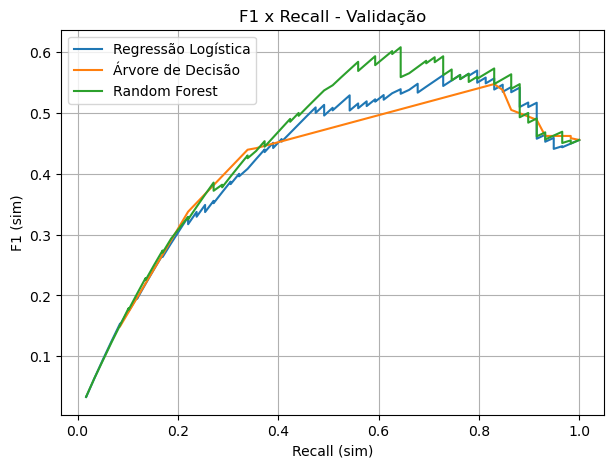

In [53]:
# Aqui a ideia é a mesma, e novamente RF parece melhor.
# Em boa parte do gráfico, eles ficam empatados, porém há um descolamento de RF em relação aos outros
# quando andamos entre 0.5 e 0.7 de recall

plt.figure(figsize=(7, 5))

for nome, proba_val in modelos_proba_val.items():
    precision, recall, thresholds = metrics.precision_recall_curve(y_val, proba_val)
    precision, recall = precision[:-1], recall[:-1]
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    plt.plot(recall, f1, label=nome)

plt.xlabel("Recall (sim)")
plt.ylabel("F1 (sim)")
plt.title("F1 x Recall - Validação")
plt.legend()
plt.grid(True)
plt.show()

## 5. Modelo Escolhido: Random Forest

### 5.1. Escolha o melhor threshold 

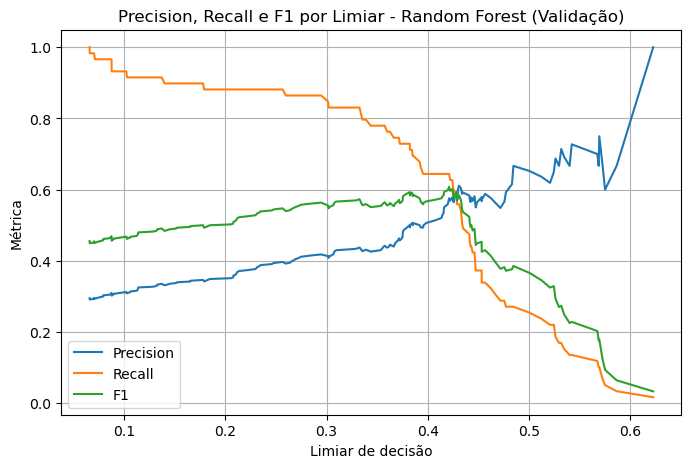

In [54]:
# Depois de comparar os modelos entre si e selecionar o Random Forest como o candidato mais interessante,
# é necessário escolher o critério de limiar mais adequado para classificação
# A decisão desse valor geralmente é mais baseado no problema que estamos tentando resolver, tradeoffs, etc, então
# não é tão simples em uma base sintética. Para ajudar aqui vou utilizar o gráfico para comparar as métricas 
# dentro do modelo de RF
# 
# Aqui por exemplo, eu imagino que um Falso Negativo é pior que um Falso Positivo em termos de risco. Porque 
# mesmo que analisemos mais carros com FP (custo), o problema de deixar passar carros que precisariam de um
# recall de fato (FN) parece bem pior
# 
# Como não vamos ter esses custos para uma análise mais profunda, eu decidi optar por utilizar o ponto de maximização
# do F1-score, porque ele me da um bom equilibrio entre Precisão x Recall
# 
# Olhando o gráfico o ponto seria 0.42 

precision, recall, thresholds = metrics.precision_recall_curve(y_val, y_val_rand_forest_proba)

precision, recall = precision[:-1], recall[:-1]
f1 = 2 * precision * recall / (precision + recall + 1e-9)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision, label="Precision")
plt.plot(thresholds, recall, label="Recall")
plt.plot(thresholds, f1, label="F1")
plt.xlabel("Limiar de decisão")
plt.ylabel("Métrica")
plt.title("Precision, Recall e F1 por Limiar - Random Forest (Validação)")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# Olhando o valor exato e métricas no ponto:

melhor_limiar = thresholds[np.argmax(f1)]
print("Limiar que maximiza F1:", round(melhor_limiar, 4))
print("Precision nesse ponto:", round(precision[np.argmax(f1)], 4))
print("Recall nesse ponto:", round(recall[np.argmax(f1)], 4))
print("F1 nesse ponto:", round(f1.max(), 4))

Limiar que maximiza F1: 0.4211
Precision nesse ponto: 0.5758
Recall nesse ponto: 0.6441
F1 nesse ponto: 0.608


### 5.2. K-Fold Validation

In [56]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# A ideia aqui é só mais uma validação para ver se os resultados não foram sorte.
# Então fazemos uma série de amostras aletórias entre treino e teste e verificamos se os resultados estão estáveis

X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

print(f"Full Train: {X_full_train.shape[0]} linhas")

Full Train: 800 linhas


In [57]:
# Olhando para o valor de ROC nas 5 iteraçõe, temos um valor relativamente estável, entre 0,800 e 0,668, então a separação
# que encontramos no nosso modelo faz sentido e não foi acaso. As métricas f1, Recall e Precision variam bastante por causa
# de dois motivo acredito: uma base pequena de dados e também porque o limiar padrão da função é 0.5, que não é o ideal.
# Isso já nos indica o motivo de utilizar o AUC para tunar os hiperparâmetros, e depois focar no threshold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

resultados_cv = cross_validate(
    rand_forest_pipeline,
    X_full_train[features],
    y_full_train,
    cv=cv,
    scoring=["f1", "roc_auc", "precision", "recall"],
    return_train_score=True
)

pd.DataFrame(resultados_cv)

,fit_time,score_time,test_f1,train_f1,test_roc_auc,train_roc_auc,test_precision,train_precision,test_recall,train_recall
0,1.479652,0.233483,0.338983,0.349206,0.799755,0.781282,0.833333,0.721311,0.212766,0.230366
1,1.573535,0.242495,0.245614,0.292887,0.745340,0.788483,0.700000,0.729167,0.148936,0.183246
2,1.585041,0.265372,0.333333,0.412214,0.772507,0.784760,0.611111,0.750000,0.229167,0.284211
3,1.536743,0.311109,0.312500,0.459854,0.667969,0.807883,0.625000,0.750000,0.208333,0.331579
4,1.646961,0.329709,0.428571,0.387833,0.790272,0.780854,0.681818,0.698630,0.312500,0.268421


### 5.3. Tunning dos Hiperparâmetros

In [60]:
from sklearn.model_selection import GridSearchCV

# Como decidi e percebi que era melhor utilizar o AUC como critério, vamos utilizar ele
# como parâmetro do gridsearch. Além disso já utilizei o dataset de treino completo depois
# de rodar o K-Fold ficou perceptivel que a base pequena da uma afetada no modelo.

param_grid = {
    "model__n_estimators": [200, 500, 1000],
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [10, 20, 30],
}

grid_search = GridSearchCV(
    estimator=rand_forest_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train[features], y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [4, 6, ...], 'model__min_samples_leaf': [10, 20, ...], 'model__n_estimators': [200, 500, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [61]:
# Os resultados do tunning não foram tão interessantes nesse momento porque podemos ver que o AUC quase não muda
# e fica muito próximo do que já tínhamos com nossos parâmetros base.
# A melhoria aqui é mais uma questão de ruído que qualquer outra coisa. Como tenho uma base pequena
# acho que tem relação com isso. Mas foi interessante verificar.
# A fim de processo, vou utilizar os parâmetros indicados como "melhores" porque não vai atrapalhar nada

resultados = pd.DataFrame(grid_search.cv_results_)
resultados[["param_model__n_estimators", "param_model__max_depth", "param_model__min_samples_leaf",
            "mean_test_score", "std_test_score", "mean_train_score"]].sort_values(
    by="mean_test_score", ascending=False
).head(10)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,mean_train_score
0,200,4,10,0.751480,0.035535,0.798311
9,200,6,10,0.751140,0.037214,0.809114
10,500,6,10,0.750737,0.037775,0.809301
1,500,4,10,0.750482,0.036401,0.798129
23,1000,8,20,0.750363,0.040037,0.788222
5,1000,4,20,0.750312,0.038268,0.784357
2,1000,4,10,0.750216,0.037189,0.798212
14,1000,6,20,0.750102,0.039595,0.787147
11,1000,6,10,0.749753,0.036399,0.809794
21,200,8,20,0.749700,0.039802,0.786817


### 5.4. Treino do modelo final

In [ ]:
# Treinei o modelo agora com tudo decidido de parâmetros e posso utilizar o Full Train porque vou utilizar a
# base dados Test apenas para verificar o funcionamento, não decidir nada (que é a ideia dela)

final_rf = ensemble.RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=10,
    random_state=random_state,
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_rf)
])

final_pipeline.fit(X_full_train[features], y_full_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
